In [15]:
import torch
from networks.cnn_dilated_convolutions import CNNModel
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
import numpy as np

def activation_maximization(starting_curve,starting_tabular,model, n_steps=1000, lr=0.01, device="cpu",max_auc=100000):
    """
    Hittar den syntetiska inputen som maximerar P(M-komponent).
    Returnerar den optimerade kurvan (300,) och tabellfeatures (26,)
    """
    model.eval()
   
    curve = torch.tensor(starting_curve, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 300)
    curve = nn.Parameter(curve)
    tabular = torch.tensor(starting_tabular, dtype=torch.float32).unsqueeze(0).to(device)
    optimizer = torch.optim.Adam([curve], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    factor=0.5, 
    patience=200,   # 200 steg utan förbättring
    min_lr=1e-6,
    threshold=1e-4  # Minsta förbättring som räknas
    )
    print(curve.shape, tabular.shape)  # Debugga innan cat
    for step in range(n_steps):
        optimizer.zero_grad()
        x = torch.cat([curve,tabular],dim=1)
        score = model(x)[:,1]
        smoothness = torch.diff(curve, dim=1).pow(2).mean()
        loss = -score + 0.005 * smoothness
        loss.backward()
        optimizer.step()

        # Projicera tillbaka
        with torch.no_grad():
            auc = curve.sum()
            if auc > max_auc:
                print("Constraint")
                #curve.data = curve.data * (max_auc / auc)

        scheduler.step(score.item())
        if optimizer.param_groups[0]['lr'] <= 1e-6:
            print(f"Early stopping vid step {step}")
            break
        if step % 100 == 0:
            print(f"Step {step}: P(M-komponent) = {score.item():.4f}")

    result = x.detach().cpu().numpy()[0]
    return result[:300], result[300:]

model = CNNModel().model
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
stats = pd.read_csv('statistics_overview.csv')
curve = np.load('m_component_curve.npy')

curve, tabular = activation_maximization(curve,stats['avg'].values[300:],model, n_steps=25000, lr=1, device=device)

torch.Size([1, 300]) torch.Size([1, 26])
Step 0: P(M-komponent) = -21.3344
Step 100: P(M-komponent) = -17.1677
Step 200: P(M-komponent) = -15.9168
Step 300: P(M-komponent) = -15.3292
Step 400: P(M-komponent) = -14.3800
Step 500: P(M-komponent) = -13.8716
Step 600: P(M-komponent) = -13.5561
Step 700: P(M-komponent) = -13.2373
Step 800: P(M-komponent) = -12.9235
Step 900: P(M-komponent) = -12.6550
Step 1000: P(M-komponent) = -12.4419
Step 1100: P(M-komponent) = -12.2753
Step 1200: P(M-komponent) = -12.1756
Step 1300: P(M-komponent) = -12.1356
Step 1400: P(M-komponent) = -12.0801
Step 1500: P(M-komponent) = -12.1450
Step 1600: P(M-komponent) = -12.2271
Step 1700: P(M-komponent) = -12.2840
Step 1800: P(M-komponent) = -12.3297
Step 1900: P(M-komponent) = -12.3634
Step 2000: P(M-komponent) = -12.3868
Step 2100: P(M-komponent) = -12.4025
Step 2200: P(M-komponent) = -12.4172
Step 2300: P(M-komponent) = -12.4267
Step 2400: P(M-komponent) = -12.4337
Step 2500: P(M-komponent) = -12.4374
Step 2600

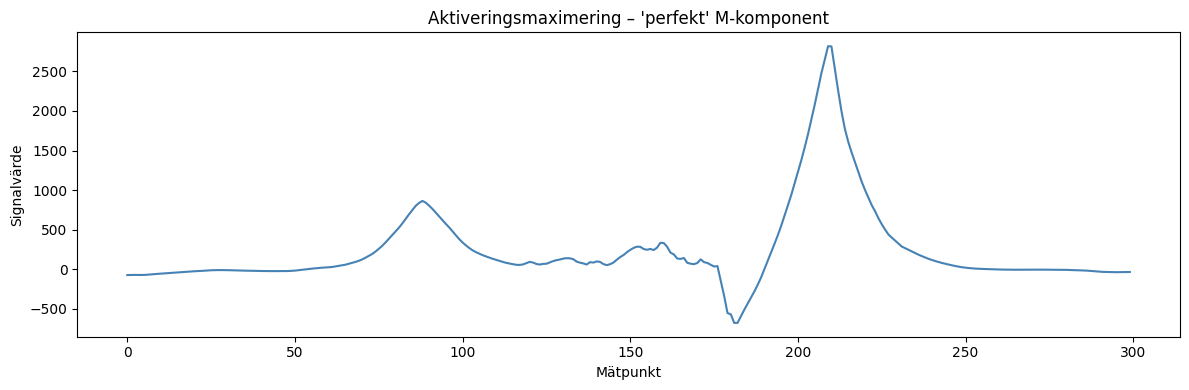

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(300), curve, color="steelblue")
ax.set_title("Aktiveringsmaximering – 'perfekt' M-komponent")
ax.set_xlabel("Mätpunkt")
ax.set_ylabel("Signalvärde")
plt.tight_layout()
plt.show()